In [1]:
import pandas as pd

df = pd.read_parquet("../data/clima_bahia_hackathon.parquet")

In [2]:
df = df.drop_duplicates()

In [3]:
colunas_uteis = [
    'ESTACAO', 'DATA (YYYY-MM-DD)', 'HORA (UTC)',
    'PRECIPITACAO TOTAL HORARIO (mm)', 
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (C)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)', 
    'RADIACAO GLOBAL (W/m2)',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
]

df = df[colunas_uteis]

In [4]:
print(df.columns.tolist())

['ESTACAO', 'DATA (YYYY-MM-DD)', 'HORA (UTC)', 'PRECIPITACAO TOTAL HORARIO (mm)', 'TEMPERATURA DO AR - BULBO SECO, HORARIA (C)', 'UMIDADE RELATIVA DO AR, HORARIA (%)', 'RADIACAO GLOBAL (W/m2)', 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)']


In [ ]:
import numpy as np
df = df.replace(-9999, np.nan)

# Ajusta a hora (ex: 300 vira 3)
df['HORA_AJUSTADA'] = (df['HORA (UTC)'] / 100).astype(int)

# Cria coluna datetime real e seta como índice
df['DATETIME'] = pd.to_datetime(df['DATA (YYYY-MM-DD)']) + pd.to_timedelta(df['HORA_AJUSTADA'], unit='h')
df = df.set_index('DATETIME').sort_index()

# ---- O FILTRO DE TEMPO PEDIDO ----
df = df[df.index.year >= 2015]

# ---- VARIÁVEIS CÍCLICAS ----
df['HORA_SIN'] = np.sin(2 * np.pi * df['HORA_AJUSTADA'] / 24.0)
df['HORA_COS'] = np.cos(2 * np.pi * df['HORA_AJUSTADA'] / 24.0)

df['MES'] = df.index.month
df['MES_SIN'] = np.sin(2 * np.pi * df['MES'] / 12.0)
df['MES_COS'] = np.cos(2 * np.pi * df['MES'] / 12.0)

# Limpa as colunas velhas de tempo
df = df.drop(columns=['DATA (YYYY-MM-DD)', 'HORA (UTC)', 'HORA_AJUSTADA', 'MES'])

In [ ]:
# Remove outlier físico de radiação
df.loc[df['RADIACAO GLOBAL (W/m2)'] > 1500, 'RADIACAO GLOBAL (W/m2)'] = np.nan

# Radiação noturna nula vira 0.0
horas_noturnas = (df.index.hour >= 19) | (df.index.hour <= 5)
df.loc[horas_noturnas & df['RADIACAO GLOBAL (W/m2)'].isna(), 'RADIACAO GLOBAL (W/m2)'] = 0.0

# Precipitação nula vira 0.0
df['PRECIPITACAO TOTAL HORARIO (mm)'] = df['PRECIPITACAO TOTAL HORARIO (mm)'].fillna(0.0)

# Forward Fill para o restante (limite de 4 horas)
cols_ffill = [
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (C)', 
    'UMIDADE RELATIVA DO AR, HORARIA (%)',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
    'RADIACAO GLOBAL (W/m2)'
]
df[cols_ffill] = df.groupby('ESTACAO')[cols_ffill].ffill(limit=4)

# Dropa linhas que permaneceram nulas
df = df.dropna()

In [7]:
df = df.sort_values(['ESTACAO', 'DATETIME'])

# Janelas de acúmulo de Chuva
df['CHUVA_ACUM_24H'] = df.groupby('ESTACAO')['PRECIPITACAO TOTAL HORARIO (mm)'].transform(lambda x: x.rolling(window=24, min_periods=1).sum())
df['CHUVA_ACUM_7D'] = df.groupby('ESTACAO')['PRECIPITACAO TOTAL HORARIO (mm)'].transform(lambda x: x.rolling(window=168, min_periods=1).sum())
df['CHUVA_ACUM_15D'] = df.groupby('ESTACAO')['PRECIPITACAO TOTAL HORARIO (mm)'].transform(lambda x: x.rolling(window=360, min_periods=1).sum())

# Janelas de estresse (Temperatura e Umidade)
df['TEMP_MED_7D'] = df.groupby('ESTACAO')['TEMPERATURA DO AR - BULBO SECO, HORARIA (C)'].transform(lambda x: x.rolling(window=168, min_periods=1).mean())
df['UMID_MED_7D'] = df.groupby('ESTACAO')['UMIDADE RELATIVA DO AR, HORARIA (%)'].transform(lambda x: x.rolling(window=168, min_periods=1).mean())

In [ ]:
# ==========================================
# Identificação de Estações Agro
# ==========================================

estacoes_agro = [
    "A402","A404","A452","A416","A424","A426","A446","A432",
    "A450","A423","A415","A448","A439","A429","A430","A441",
    "A442","A412","A436","A428","A414","A406","A408"
]

df["IS_AGRO"] = df["ESTACAO"].isin(estacoes_agro).astype(int)

In [ ]:
# ==========================================
# Separação Temporal (Os Folds)
# ==========================================

data_val = '2020-01-01'
data_test = '2021-01-01'

train_df = df[df.index < data_val].copy()
val_df = df[(df.index >= data_val) & (df.index < data_test)].copy()
test_df = df[df.index >= data_test].copy()

In [ ]:
# ==========================================
# (K-Means por Clima)
# ==========================================
from sklearn.preprocessing import StandardScaler
features_cluster = ['CHUVA_ACUM_24H', 'CHUVA_ACUM_15D', 'TEMP_MED_7D', 'UMID_MED_7D']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[features_cluster])
X_val_scaled = scaler.transform(val_df[features_cluster])
X_test_scaled = scaler.transform(test_df[features_cluster])

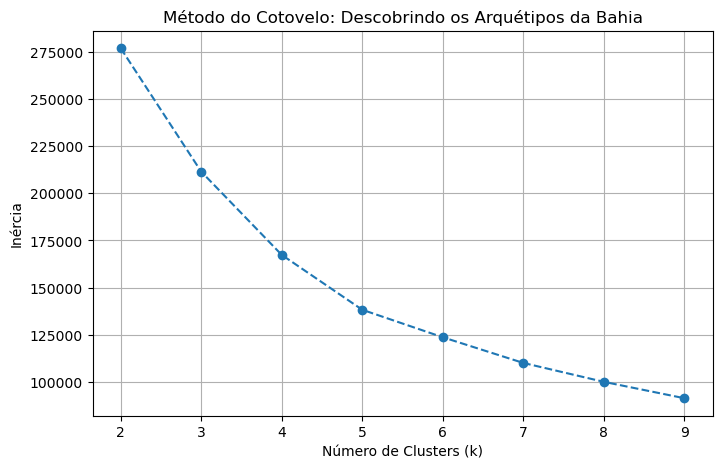

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ==========================================
amostra_indices = np.random.choice(X_train_scaled.shape[0], size=100000, replace=False)
X_amostra = X_train_scaled[amostra_indices]

inercia = []
variacao_k = range(2, 10)

for k in variacao_k:
    km_teste = KMeans(n_clusters=k, random_state=42, n_init=5)
    km_teste.fit(X_amostra)
    inercia.append(km_teste.inertia_)

# "Cotovelo"
plt.figure(figsize=(8, 5))
plt.plot(variacao_k, inercia, marker='o', linestyle='--')
plt.title('Método do Cotovelo: Descobrindo os Arquétipos da Bahia')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
import pandas as pd

# ==========================================
# 1. TESTE DO SILHOUETTE SCORE
# ==========================================
k_escolhido = 4 
kmeans_teste = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
labels_amostra = kmeans_teste.fit_predict(X_amostra)
sil_score = silhouette_score(X_amostra, labels_amostra)
print(f"Silhouette Score para k={k_escolhido}: {sil_score:.4f}")
print("Lembrete: Valores > 0.5 são ótimos. Valores entre 0.2 e 0.5 são normais em dados climáticos que têm muita transição contínua.\n")

# ==========================================
# 2. TREINO FINAL 
# ==========================================
kmeans_oficial = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
kmeans_oficial.fit(X_train_scaled)

centroides_escalados = kmeans_oficial.cluster_centers_
centroides_reais = scaler.inverse_transform(centroides_escalados)

df_arquetipos = pd.DataFrame(
    centroides_reais, 
    columns=features_cluster 
)
df_arquetipos.index.name = 'ID_do_Cluster'

print("--- A CARA DOS ARQUÉTIPOS CLIMÁTICOS NA BAHIA ---")
print(df_arquetipos.round(2))

Silhouette Score para k=4: 0.3340
Lembrete: Valores > 0.5 são ótimos. Valores entre 0.2 e 0.5 são normais em dados climáticos que têm muita transição contínua.

--- A CARA DOS ARQUÉTIPOS CLIMÁTICOS NA BAHIA ---
               CHUVA_ACUM_24H  CHUVA_ACUM_15D  TEMP_MED_7D  UMID_MED_7D
ID_do_Cluster                                                          
0                        1.22           22.93        22.99        78.16
1                        3.78          116.35        24.10        82.53
2                        0.54            9.31        26.43        57.79
3                       40.36          111.01        24.71        79.04


In [ ]:
from scipy.spatial import distance

centroides_padronizados = kmeans_oficial.cluster_centers_

id_ideal = 1 

distancias_do_ideal = []
for i in range(len(centroides_padronizados)):
    dist = distance.euclidean(centroides_padronizados[id_ideal], centroides_padronizados[i])
    distancias_do_ideal.append(dist)

distancias_do_ideal = np.array(distancias_do_ideal)

pesos_risco_centroides = distancias_do_ideal / np.max(distancias_do_ideal)

print("--- PESOS CALCULADOS PELA IA ---")
for i, peso in enumerate(pesos_risco_centroides):
    print(f"Cluster {i}: Peso {peso:.2f}")

--- PESOS CALCULADOS PELA IA ---
Cluster 0: Peso 0.43
Cluster 1: Peso 0.00
Cluster 2: Peso 0.63
Cluster 3: Peso 1.00


In [ ]:
def calcular_indice_risco(X_scaled, modelo_kmeans, pesos):
    distancias = modelo_kmeans.transform(X_scaled)
    dist_inv = 1.0 / (distancias + 1e-8)
    prob_clusters = dist_inv / dist_inv.sum(axis=1, keepdims=True)
    indice_geral = np.sum(prob_clusters * pesos, axis=1) * 100
    return indice_geral

# Criando a coluna do ÍNDICE REAL [target]
train_df['INDICE_VULNERABILIDADE'] = calcular_indice_risco(X_train_scaled, kmeans_oficial, pesos_risco_centroides)
val_df['INDICE_VULNERABILIDADE'] = calcular_indice_risco(X_val_scaled, kmeans_oficial, pesos_risco_centroides)
test_df['INDICE_VULNERABILIDADE'] = calcular_indice_risco(X_test_scaled, kmeans_oficial, pesos_risco_centroides)

In [ ]:
def extrair_ameaca_principal(X_scaled, modelo_kmeans):
    distancias = modelo_kmeans.transform(X_scaled)
    dist_inv = 1.0 / (distancias + 1e-8)
    
    id_maior_risco = np.argmax(dist_inv, axis=1)

    mapa_ameacas = {
        0: 'Clima de Atenção (Ameno)',
        1: 'Condição Ideal (Sem Risco)',
        2: 'Risco de Seca Severa',
        3: 'Risco de Enchente/Alagamento'
    }
    
    nomes_ameacas = [mapa_ameacas[id_cluster] for id_cluster in id_maior_risco]
    return nomes_ameacas

train_df['STATUS_MOMENTO'] = extrair_ameaca_principal(X_train_scaled, kmeans_oficial)

In [16]:
display(train_df)

,ESTACAO,PRECIPITACAO TOTAL HORARIO (mm),"TEMPERATURA DO AR - BULBO SECO, HORARIA (C)","UMIDADE RELATIVA DO AR, HORARIA (%)",RADIACAO GLOBAL (W/m2),"PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",HORA_SIN,HORA_COS,MES_SIN,MES_COS,CHUVA_ACUM_24H,CHUVA_ACUM_7D,CHUVA_ACUM_15D,TEMP_MED_7D,UMID_MED_7D,IS_AGRO,INDICE_VULNERABILIDADE,STATUS_MOMENTO
DATETIME,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,A401,0.0,25.6,80.0,0.0,1009.5,0.000000,1.000000,5.000000e-01,0.866025,0.0,0.0,0.0,25.600000,80.000000,0,45.713847,Clima de Atenção (Ameno)
2015-01-01 01:00:00,A401,0.0,25.5,80.0,0.0,1009.6,0.258819,0.965926,5.000000e-01,0.866025,0.0,0.0,0.0,25.550000,80.000000,0,45.668831,Clima de Atenção (Ameno)
2015-01-01 02:00:00,A401,0.0,25.4,81.0,0.0,1009.0,0.500000,0.866025,5.000000e-01,0.866025,0.0,0.0,0.0,25.500000,80.333333,0,45.548338,Clima de Atenção (Ameno)
2015-01-01 03:00:00,A401,0.0,25.2,81.0,0.0,1008.4,0.707107,0.707107,5.000000e-01,0.866025,0.0,0.0,0.0,25.425000,80.500000,0,45.445635,Clima de Atenção (Ameno)
2015-01-01 04:00:00,A401,0.0,25.1,83.0,0.0,1008.2,0.866025,0.500000,5.000000e-01,0.866025,0.0,0.0,0.0,25.360000,81.000000,0,45.285355,Clima de Atenção (Ameno)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 19:00:00,A458,0.0,27.8,58.0,345.1,988.4,-0.965926,0.258819,-2.449294e-16,1.000000,8.0,8.0,8.6,26.576786,70.363095,0,48.834842,Risco de Seca Severa
2019-12-31 20:00:00,A458,0.0,25.1,82.0,404.2,988.7,-0.866025,0.500000,-2.449294e-16,1.000000,8.0,8.0,8.6,26.567262,70.464286,0,48.796927,Risco de Seca Severa
2019-12-31 21:00:00,A458,0.0,25.2,82.0,143.5,989.1,-0.707107,0.707107,-2.449294e-16,1.000000,3.2,8.0,8.6,26.564286,70.523810,0,49.696525,Risco de Seca Severa


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# ==========================================
# Janela de 72 horas
# ==========================================
horas_futuro = 72

for df in [train_df, val_df, test_df]:
    df['TARGET_INDICE_72H'] = df.groupby('ESTACAO')['INDICE_VULNERABILIDADE'].shift(-horas_futuro)

train_ml = train_df.dropna(subset=['TARGET_INDICE_72H'])
val_ml = val_df.dropna(subset=['TARGET_INDICE_72H'])
test_ml = test_df.dropna(subset=['TARGET_INDICE_72H'])

# ==========================================
#  SEPARANDO O X E O Y 
# ==========================================
features_xgb = [
    'CHUVA_ACUM_24H', 'CHUVA_ACUM_15D', 'TEMP_MED_7D', 'UMID_MED_7D',
    'PRECIPITACAO TOTAL HORARIO (mm)', 'TEMPERATURA DO AR - BULBO SECO, HORARIA (C)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)', 'RADIACAO GLOBAL (W/m2)', 
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
    'HORA_SIN', 'HORA_COS', 'MES_SIN', 'MES_COS', 'IS_AGRO'
]

X_train_xgb = train_ml[features_xgb]
X_val_xgb = val_ml[features_xgb]
X_test_xgb = test_ml[features_xgb]

y_train_reg = train_ml['TARGET_INDICE_72H']
y_val_reg = val_ml['TARGET_INDICE_72H']
y_test_reg = test_ml['TARGET_INDICE_72H']

# ==========================================
#  TREINANDO  
# ==========================================
print("Treinando XGBoost Regressor (Índice de 0 a 100)...")
modelo_xgb_reg = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=10, min_child_weight=3, random_state=42, n_jobs=-1)
modelo_xgb_reg.fit(X_train_xgb, y_train_reg)

rmse_val = mean_squared_error(y_val_reg, modelo_xgb_reg.predict(X_val_xgb), squared=False)
print(f"-> RMSE Regressão (Validação): {rmse_val:.2f} pontos de Índice")

Treinando XGBoost Regressor (Índice de 0 a 100)...
-> RMSE Regressão (Validação): 5.46 pontos de Índice



  AVALIAÇÃO FINAL DO MODELO PREDITIVO (Teste 2021+)

--- MÉTRICAS DE PRECISÃO (Regressão) ---
RMSE (Raiz do Erro Quadrático Médio) : 3.68
MAE  (Erro Absoluto Médio)           : 1.87 pontos
R²   (Coeficiente de Determinação)   : 0.7183



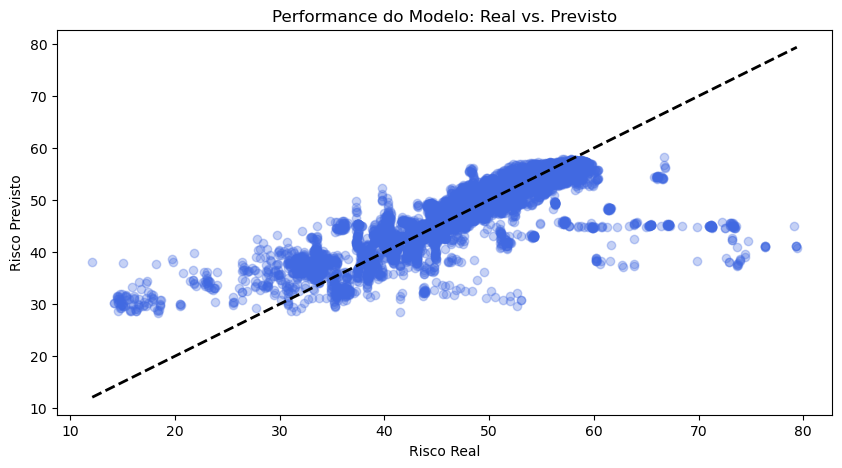

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n=======================================================")
print("  AVALIAÇÃO FINAL DO MODELO PREDITIVO (Teste 2021+)")
print("=======================================================\n")

previsoes_test_reg = modelo_xgb_reg.predict(X_test_xgb)

rmse_test = mean_squared_error(y_test_reg, previsoes_test_reg, squared=False)
mae_test = mean_absolute_error(y_test_reg, previsoes_test_reg)
r2_test = r2_score(y_test_reg, previsoes_test_reg)

print(f"--- MÉTRICAS DE PRECISÃO (Regressão) ---")
print(f"RMSE (Raiz do Erro Quadrático Médio) : {rmse_test:.2f}")
print(f"MAE  (Erro Absoluto Médio)           : {mae_test:.2f} pontos")
print(f"R²   (Coeficiente de Determinação)   : {r2_test:.4f}\n")

plt.figure(figsize=(10, 5))
plt.scatter(y_test_reg, previsoes_test_reg, alpha=0.3, color='royalblue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2)
plt.xlabel('Risco Real')
plt.ylabel('Risco Previsto')
plt.title('Performance do Modelo: Real vs. Previsto')
plt.show()

In [ ]:
import joblib
import json

# ==========================================
# Exportando modelo
# ==========================================

joblib.dump(scaler, '../backend/models/scaler.pkl')
joblib.dump(kmeans_oficial, '../backend/models/kmeans.pkl')
joblib.dump(modelo_xgb_reg, '../backend/models/xgboost.pkl')

config = {
    'id_ideal':     int(id_ideal),
    'pesos':        pesos_risco_centroides.tolist(),
    'features_cluster': features_cluster,
    'features_xgb':     features_xgb,
}

with open('../backend/models/config.json', 'w') as f:
    json.dump(config, f)